# Solution of NX-465 Mini-project MP2
## Spatial Navigation using Grid Cells: Path Integration in 2D Space
**Spring semester 2026**

*Team members: Kamegne Yann Eddy Sipofo & Arthur Stefano Moscheni*


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d, convolve
from tqdm.auto import tqdm

# Global simulation parameters
tau = 10.0   # membrane time constant (ms)
dt= 1.0    # integration time step (ms)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

---
## Exercise 0 — Getting Started: Ring Attractors in 1D

We simulate a field model for a 1D ring of neurons. The potential $s(x,t)$ evolves as:

$$\tau \frac{ds(x,t)}{dt} = -s(x,t) + I^{rec}(x,t) + B(x,t)$$

with recurrent input (convolution of firing rate with a Mexican-hat kernel):

$$I^{rec}(x,t) = \int W(x-x')\,r(x',t)\,dx', \qquad r(x,t)=\max(0,\,s(x,t))$$

$$W(x) = A_{exc}\,e^{-x^2/\sigma_{exc}^2} - A_{inh}\,e^{-x^2/\sigma_{inh}^2}$$

**0.1.** Write a Python function `mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)` that computes
the 1D interaction weight at distance $x$.

**0.2.** Plot the weight kernel for an array of $M = 100$ neurons centered around 0
($x \in [-M/2,\,M/2)$, equally spaced), using parameters:
$A_{exc}=0.3$, $\sigma_{exc}=5.0$, $A_{inh}=0.2$, $\sigma_{inh}=10.0$.


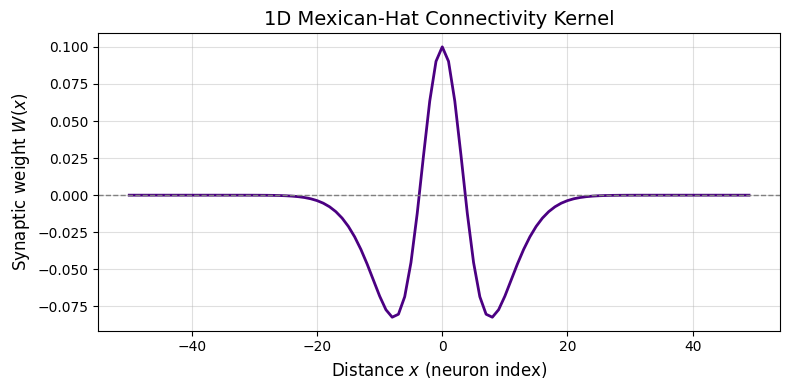

In [ ]:
# Exercise 0.1 & 0.2

def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    """W(x) = A_exc * exp(-x²/σ_exc²) - A_inh * exp(-x²/σ_inh²)"""
    return (  A_exc * np.exp(-(x**2) / sigma_exc**2)
            - A_inh * np.exp(-(x**2) / sigma_inh**2))

M = 100
A_exc = 0.3;  sigma_exc = 5.0
A_inh = 0.2;  sigma_inh = 10.0

x_vals = np.arange(-M /2, M / 2)
W_1d = mexican_hat_1d(x_vals, A_exc, sigma_exc, A_inh, sigma_inh)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vals, W_1d, color='indigo', lw=2)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Distance $x$ (neuron index)')
ax.set_ylabel('Synaptic weight $W(x)$')
ax.set_title('1D Mexican-Hat Connectivity Kernel')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**0.3. Biological interpretation of the Mexican-hat kernel**

The Mexican-hat profile represents an *effective* anatomical coupling within the cortical sheet. The short-range positive lobe reflects local recurrent excitation between nearby pyramidal cells. The broader negative surround accounts for the effective long-range lateral inhibition mediated by local interneurons, which receive local excitatory input but project inhibitory synapses over significantly greater distances than the excitatory cells.


**0.4.** Use the Forward Euler method with $\Delta t = 1$ ms to integrate the dynamics of this
1D network over 500 ms. Plot the evolution of the firing rate $r(x,t)$.

Parameters: $\tau=10$ ms, $B(x,t)=1.0$. Randomly initialise $s(x,0)\sim\text{Uniform}(0,0.1)$.

*Hint:* implement the convolution $\int W(x-x')r(x')\,dx'$ with `scipy.ndimage.convolve1d`
using `mode='wrap'` for periodic boundaries.


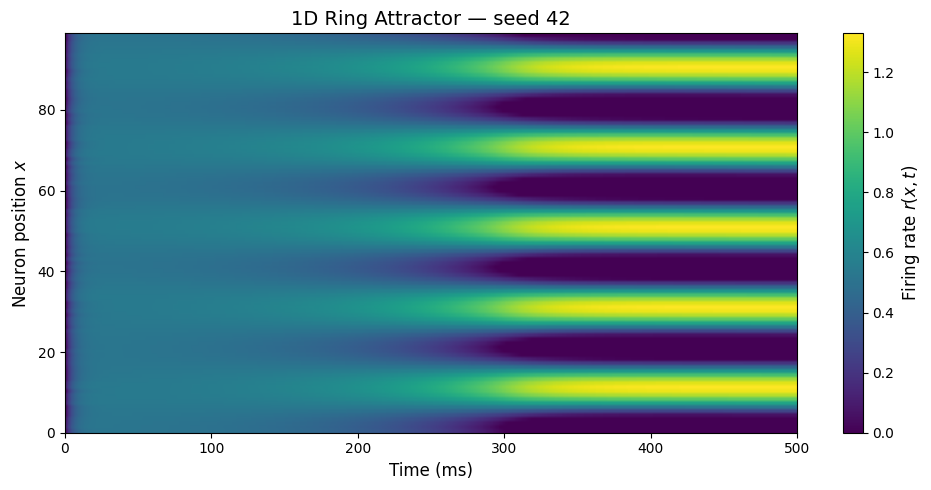

In [ ]:
# Exercise 0.4

def simulate_1d_ring(seed, T=500.0, B=1.0):
    """1D ring attractor. Returns rate history (n_steps, M)."""
    np.random.seed(seed)
    n_steps= int(T / dt)
    s = np.random.uniform(0.0, 0.1, M)
    rates_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        r = np.maximum(0.0, s)
        rates_hist[t] = r
        I_rec = convolve1d(r, W_1d, mode='wrap')
        s = s+ dt * (-s + I_rec + B) / tau

    return rates_hist

seed_demo = 42
rates_demo = simulate_1d_ring(seed=seed_demo)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(rates_demo.T, aspect='auto', origin='lower',
               extent=[0, 500, 0, M - 1], cmap='viridis')
plt.colorbar(im, ax=ax, label='Firing rate $r(x,t)$')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron position $x$')
ax.set_title(f'1D Ring Attractor — seed {seed_demo}')
plt.tight_layout()
plt.show()

**0.5.** Describe the behaviour of the network using 3 different random seeds.
Does the behaviour depend on the initialisation of $s(x,0)$?


/var/folders/pl/0p2t5g6s7w166xlgbnr_0zq40000gn/T/ipykernel_28703/2375668523.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


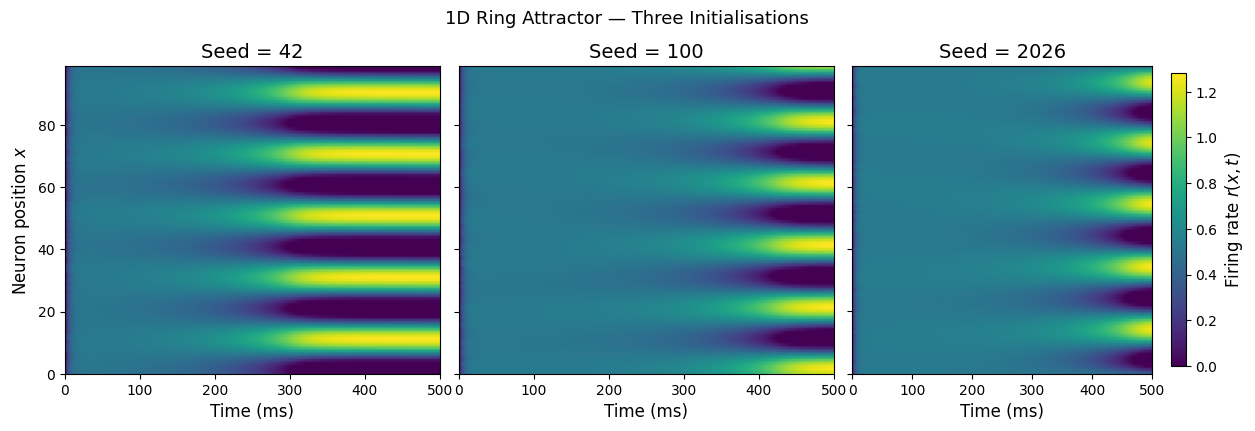

In [ ]:
# Exercise 0.5

seeds = [42, 100, 2026]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True,
                         gridspec_kw={'wspace': 0.05})
for ax, seed in zip(axes, seeds):
    rates = simulate_1d_ring(seed=seed)
    im = ax.imshow(rates.T, aspect='auto', origin='lower',
                      extent=[0, 500, 0, M - 1], cmap='viridis')
    ax.set_title(f'Seed = {seed}')
    ax.set_xlabel('Time (ms)')

axes[0].set_ylabel('Neuron position $x$')
fig.colorbar(im, ax=axes[2], label='Firing rate $r(x,t)$', shrink=0.95)
plt.suptitle('1D Ring Attractor — Three Initialisations', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('images2/fig_0_5_seeds.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Ex 0.5):**

The network's macroscopic equilibrium state — a localized activity bump — is robust and *independent* of the initial noise. However, its exact spatial phase (location) is entirely determined by the initial conditions via spontaneous symmetry breaking. This defines a **continuous attractor**: the network possesses a continuous manifold of marginally stable fixed points that are translationally equivalent, enabling it to maintain a persistent spatial memory devoid of predefined boundaries.


---
## Exercise 1 — 1D Velocity Integration

To track velocity we split the population into two sub-populations:
a **right-shifting** (R) and a **left-shifting** (L) population, each of $M=100$ neurons.
Their shifted kernels are:

$$W_R(x-x') = W(x-x'-l), \qquad W_L(x-x') = W(x-x'+l)$$

and the external inputs are modulated asymmetrically by velocity $v(t)$:

$$B_R = B_0(1+\alpha v(t)), \qquad B_L = B_0(1-\alpha v(t))$$

The total recurrent input to any neuron is the sum from both populations:

$$I^{rec}(x,t)=\int W_R(x-x')r_R(x',t)\,dx' + \int W_L(x-x')r_L(x',t)\,dx'$$

**1.1.** Write a simulation function for this 2-population integrator.
Parameters: $B_0=1.5$, $\alpha=0.5$, $l=1.0$.
Run for 1000 ms: $v=0$ for the first 300 ms (let bump stabilise), $v=1.0$ from 300–700 ms,
$v=0$ afterwards. Plot $r_{total}(x,t) = r_R(x,t)+r_L(x,t)$ over time.


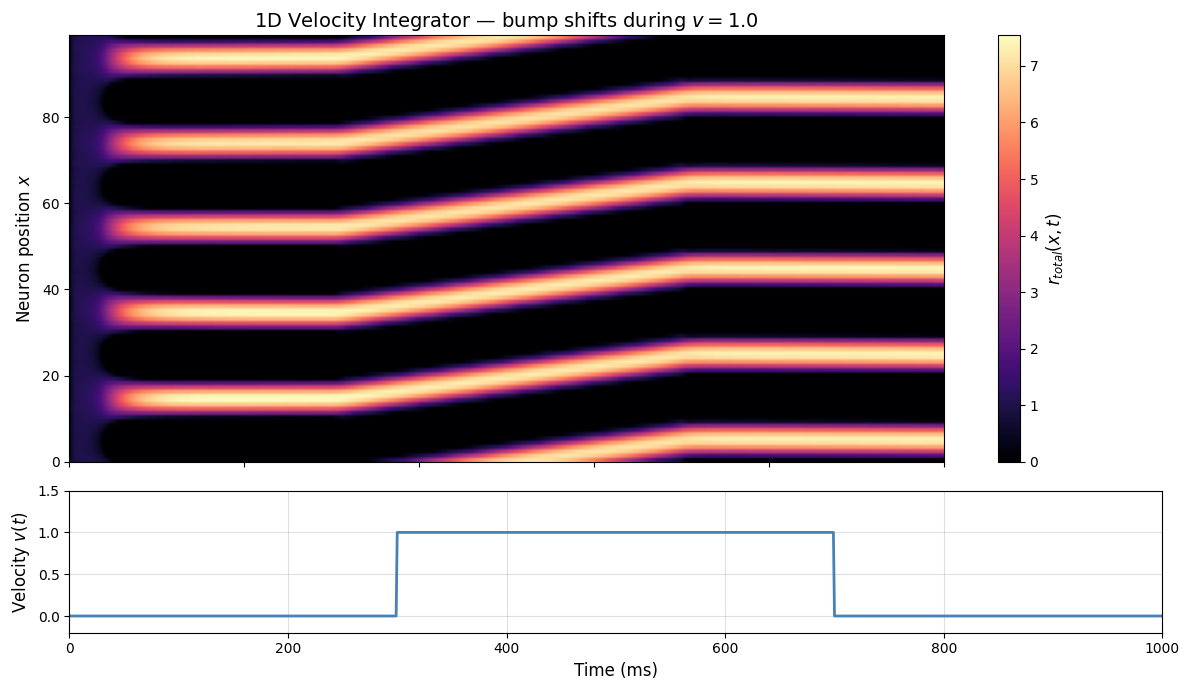

In [ ]:
# Exercise 1.1

B0= 1.5
alpha = 0.5
l = 1.0   # kernel shift (neuron-index units)

WR_1d = mexican_hat_1d(x_vals - l, A_exc, sigma_exc, A_inh, sigma_inh)
WL_1d = mexican_hat_1d(x_vals + l, A_exc, sigma_exc, A_inh, sigma_inh)


def simulate_1d_integrator(v_arr, T=1000.0, seed=42):
    """1D velocity integrator (R/L populations). Returns r_total history (n_steps, M)."""
    np.random.seed(seed)
    n_steps = int(T / dt)

    s_R = np.random.uniform(0.0, 0.1, M)
    s_L = np.random.uniform(0.0, 0.1, M)
    r_total_hist = np.zeros((n_steps, M))

    for t in range(n_steps):
        v = v_arr[t]
        r_R = np.maximum(0.0, s_R)
        r_L = np.maximum(0.0, s_L)

        r_total_hist[t] = r_R + r_L

        I_rec = (convolve1d(r_R, WR_1d, mode='wrap') + convolve1d(r_L, WL_1d, mode='wrap'))

        B_R = B0 * (1 + alpha * v)
        B_L = B0 * (1 - alpha * v)

        s_R = s_R + dt * (-s_R + I_rec + B_R) / tau
        s_L = s_L + dt * (-s_L + I_rec + B_L) / tau

    return r_total_hist


T11= 1000.0
n11 = int(T11 / dt)
time_11 = np.arange(n11) * dt

v_11 = np.zeros(n11)
v_11[(time_11 >= 300) & (time_11 < 700)] = 1.0

r_hist_11 = simulate_1d_integrator(v_11, T=T11)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
im = axes[0].imshow(r_hist_11.T, aspect='auto', origin='lower',
                    extent=[0, T11, 0, M - 1], cmap='magma')
fig.colorbar(im, ax=axes[0], label=r'$r_{total}(x,t)$')
axes[0].set_ylabel('Neuron position $x$')
axes[0].set_title('1D Velocity Integrator — bump shifts during $v=1.0$')

axes[1].plot(time_11, v_11, color='steelblue', lw=2)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Velocity $v(t)$')
axes[1].set_ylim(-0.2, 1.5)
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**1.2. Mechanism of velocity-driven shifting**

When $v > 0$, the right-shifting population receives a stronger feedforward drive ($B_R > B_L$). Due to the anatomically shifted recurrent kernel $W_R$, the R neurons preferentially project their maximal excitation ahead of the current bump position (by a spatial offset $l$). This structural asymmetry, combined with the firing rate imbalance, systematically biases the recurrent excitatory input towards the right flank of the bump, while simultaneously inhibiting the left flank via the Mexican-hat surround. As a result, the entire activity profile translates rightward. The drift speed is dictated by the amplitude of $v$, which governs the magnitude of the feedforward imbalance $B_R - B_L = 2\alpha B_0 v$. A negative velocity ($v < 0$) symmetrically recruits the L population, driving a leftward translation.


**1.3.** To show that the bump acts as a velocity integrator, apply a velocity signal of
varying magnitudes over time. Sample 10 velocities in $[-2,-0.5]\cup[0.5,2]$, each lasting
300 timesteps. Plot the bump evolution and velocity signal side by side.


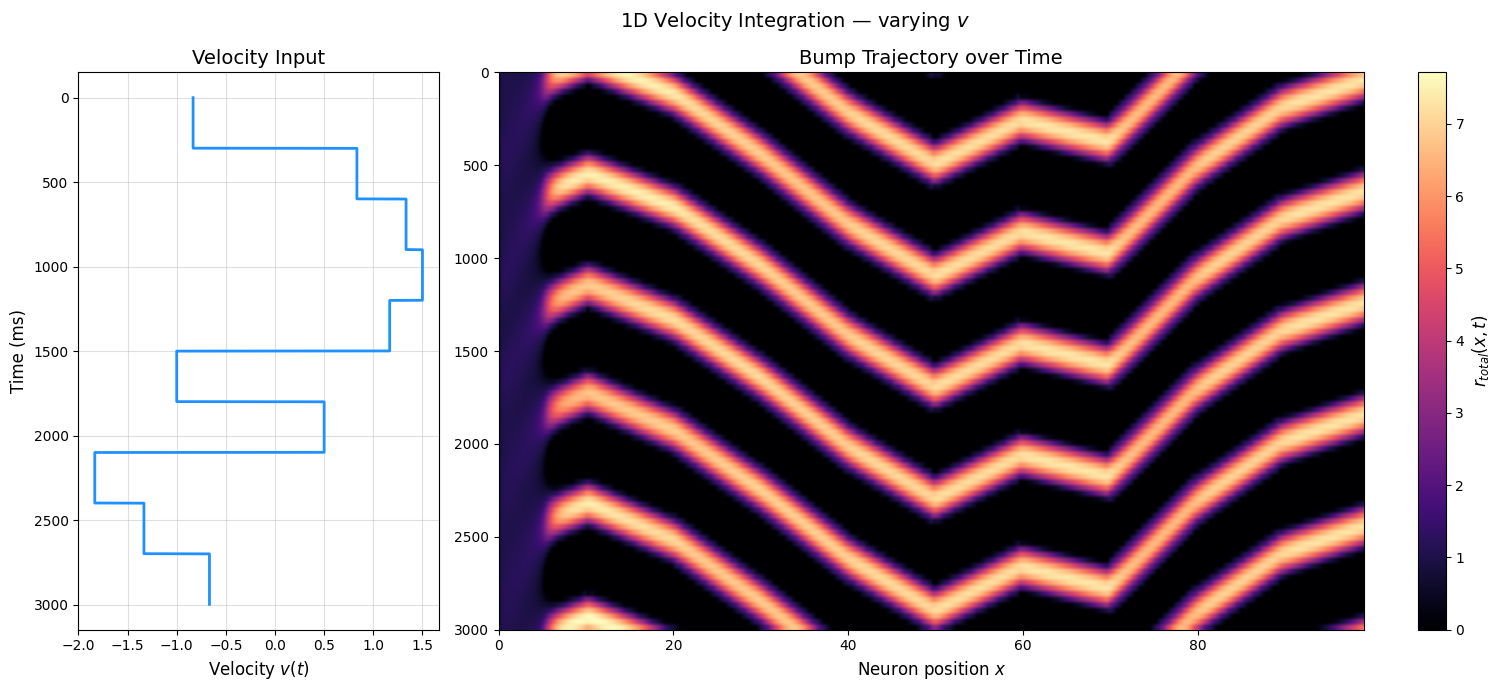

In [ ]:
# Exercise 1.3

rng = np.random.default_rng(7)
pool = np.concatenate([np.linspace(-2.0, -0.5, 10),
                           np.linspace( 0.5,  2.0, 10)])
v_samples = rng.choice(pool, size=10, replace=False)

block = 300
T13 = block * 10
n13 = T13
time_13 = np.arange(n13) * dt

v_13 = np.zeros(n13)
for i, vi in enumerate(v_samples):
    v_13[i * block : (i + 1) * block] = vi

r_hist_13 = simulate_1d_integrator(v_13, T=float(T13))

fig, (ax_v, ax_r) = plt.subplots(1, 2, figsize=(16, 7),
                                  gridspec_kw={'width_ratios': [1, 3]})
ax_v.plot(v_13, time_13, color='dodgerblue', lw=2)
ax_v.set_xlabel('Velocity $v(t)$')
ax_v.set_ylabel('Time (ms)')
ax_v.set_title('Velocity Input')
ax_v.grid(True, alpha=0.4)
ax_v.invert_yaxis()

im = ax_r.imshow(r_hist_13.T, aspect='auto', origin='upper',
                 extent=[0, M - 1, T13, 0], cmap='magma')
fig.colorbar(im, ax=ax_r, label=r'$r_{total}(x,t)$')
ax_r.set_xlabel('Neuron position $x$')
ax_r.set_title('Bump Trajectory over Time')

plt.suptitle('1D Velocity Integration — varying $v$', fontsize=14)
plt.tight_layout()
plt.show()

**Observation (Ex 1.3):**

The bump moves at a speed proportional to $v(t)$, instantly reversing direction upon each velocity switch, while its shape remains stable. It wraps around the ring boundaries without disruption, confirming the periodic topology. The bump's cumulative displacement tracks the time-integral of velocity, demonstrating that the network performs path integration

**1.4.** Devise a method to compute the velocity of the moving bump. Plot measured bump velocity
vs. input velocity and check for a linear relationship.


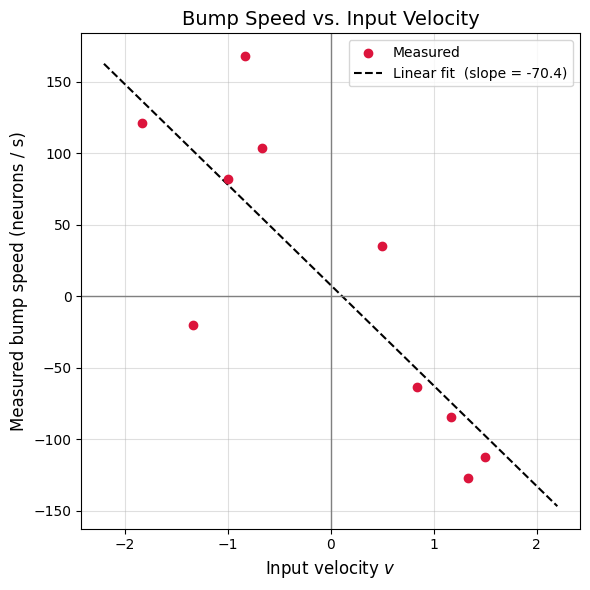

Linear fit: bump_speed ≈ -70.35 · v + 7.89


In [ ]:
# Exercise 1.4

def bump_phase(r_row):
    """Angular position of the bump on the ring via first Fourier mode."""
    positions = np.arange(len(r_row))
    f_comp    = np.sum(r_row * np.exp(-1j * 2 * np.pi * positions / len(r_row)))
    return np.angle(f_comp)

phases_13 = np.array([bump_phase(r_hist_13[t]) for t in range(n13)])
phases_13_unwrapped = np.unwrap(phases_13)

phase_speed = np.diff(phases_13_unwrapped) / (2 * np.pi) * M  # neurons / ms

transient = 100
measured_v = []
input_v = []

for i in range(10):
    s_idx = i * block + transient
    e_idx = (i + 1) * block - transient
    measured_v.append(np.mean(phase_speed[s_idx:e_idx]) * 1000)
    input_v.append(v_samples[i])

measured_v = np.array(measured_v)
input_v = np.array(input_v)

coeffs= np.polyfit(input_v, measured_v, 1)
v_range = np.linspace(-2.2, 2.2, 100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(input_v, measured_v, color='crimson', zorder=5, label='Measured')
ax.plot(v_range, np.poly1d(coeffs)(v_range), 'k--',
        label=f'Linear fit  (slope = {coeffs[0]:.1f})')
ax.axhline(0, color='gray', lw=1)
ax.axvline(0, color='gray', lw=1)
ax.set_xlabel('Input velocity $v$')
ax.set_ylabel('Measured bump speed (neurons / s)')
ax.set_title('Bump Speed vs. Input Velocity')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Linear fit: bump_speed ≈ {coeffs[0]:.2f} · v + {coeffs[1]:.2f}")

**Result (Ex 1.4):**

The measured bump drift speed scales linearly with the input velocity $v$ (black dashed fit, slope ≈ −70.4 neurons/s), confirming that the network operates as a faithful velocity integrator. To measure the bump speed, we compute the angular phase of the activity pattern at each timestep using the first Fourier mode: the activity vector is projected onto a complex exponential, and the angle of the resulting complex number gives the bump's position on the ring. After phase unwrapping to remove artificial jumps when the bump crosses the ring boundary, the bump speed is obtained by finite differencing consecutive phase values. Averaging over each constant-velocity block and plotting measured speed against input velocity $v$ reveals a clear linear relationship (slope ≈ −70.4 neurons/s), confirming that the network faithfully and proportionally integrates the velocity input.


---
## Exercise 2 — Extending to 2D Grid Cells

Equations (1)–(3) extend directly to 2D with $\|\mathbf{x}\| = \sqrt{x^2+y^2}$:

$$W(\mathbf{x}) = A_{exc}\,e^{-\|\mathbf{x}\|^2/\sigma_{exc}^2}
                 - A_{inh}\,e^{-\|\mathbf{x}\|^2/\sigma_{inh}^2}$$

**2.1.** Plot the 2D mexican-hat kernel for $M=40$, $A_{exc}=A_{inh}=1.0$,
$\sigma_{exc}=4.8$, $\sigma_{inh}=5.0$.


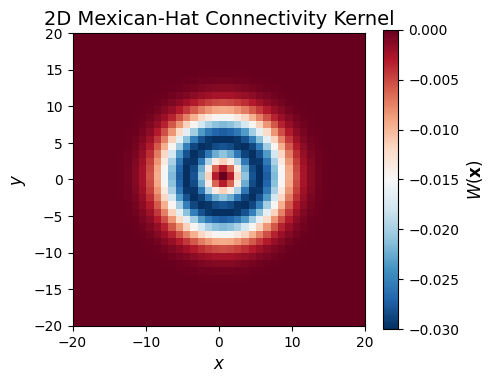

In [ ]:
# Exercise 2.1

M2 = 40
A2_exc = 1.0;  sigma2_exc = 4.8
A2_inh = 1.0;  sigma2_inh = 5.0

gy, gx = np.mgrid[-M2 // 2 : M2 // 2, -M2 // 2 : M2 // 2]

def mexican_hat_2d(X, Y, A_exc, s_exc, A_inh, s_inh):
    """W(x,y) = A_exc*exp(-r²/σ_exc²) - A_inh*exp(-r²/σ_inh²), r²=X²+Y²"""
    r2 = X**2 + Y**2
    return A_exc * np.exp(-r2 / s_exc**2) - A_inh * np.exp(-r2 / s_inh**2)

W2d = mexican_hat_2d(gx, gy, A2_exc, sigma2_exc, A2_inh, sigma2_inh)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(W2d, extent=[-M2 // 2, M2 // 2, -M2 // 2, M2 // 2],
               origin='lower', cmap='RdBu_r')
plt.colorbar(im, ax=ax, label=r'$W(\mathbf{x})$')
ax.set_title('2D Mexican-Hat Connectivity Kernel')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**2.2.** Implement the 2D model with 4 velocity-shifted populations (N, S, E, W).
Use periodic (torus) boundary conditions (`mode='wrap'`).
Simulate with $\mathbf{v}=(0,0)$ for 400 ms and plot the final total firing rate.

Parameters: $\tau=10$ ms, $\Delta t=1$ ms, $l=1.0$, $\alpha=0.1$, $B_0=1.0$.


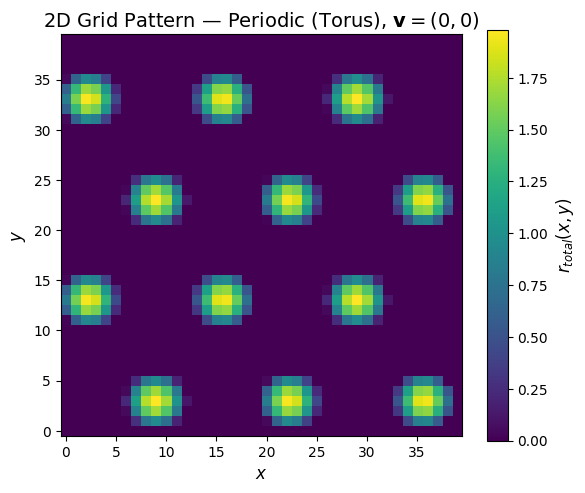

In [ ]:
# Exercise 2.2

l2 = 1.0
alpha2 = 0.1
B02 = 1.0

# Four directionally shifted kernels
gy2, gx2 = np.mgrid[-M2 // 2 : M2 // 2, -M2 // 2 : M2 // 2]
W_N2 = mexican_hat_2d(gx2, gy2 - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_S2 = mexican_hat_2d(gx2, gy2 + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_E2 = mexican_hat_2d(gx2 - l2,  gy2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_W2 = mexican_hat_2d(gx2 + l2,  gy2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
KERNELS = [W_N2, W_S2, W_E2, W_W2]


def simulate_2d(vx_arr, vy_arr, T, M_val=40,
                kernels=None, mode='wrap',
                weight_mask=None, input_mask=None, seed=42):
    """2D CAN — 4 populations (N, S, E, W). Returns (r_final, snapshots)."""
    if kernels is None:
        kernels = KERNELS
    W_N, W_S, W_E, W_W = kernels

    np.random.seed(seed)
    n_steps = int(T / dt)

    s_N = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_S = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_E = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_W = np.random.uniform(0.0, 0.1, (M_val, M_val))

    snap_times = {300, 450, 600}
    snapshots = []

    for t in range(n_steps):
        vx = vx_arr[t]
        vy = vy_arr[t]

        r_N = np.maximum(0.0, s_N)
        r_S = np.maximum(0.0, s_S)
        r_E = np.maximum(0.0, s_E)
        r_W = np.maximum(0.0, s_W)

        # Weight attenuation: scale outgoing rates near boundaries
        if weight_mask is not None:
            r_N = r_N * weight_mask
            r_S = r_S * weight_mask
            r_E = r_E * weight_mask
            r_W = r_W * weight_mask

        # Recurrent input  I_rec = sum_p (W_p * r_p)
        I_rec = (convolve(r_N, W_N, mode=mode)
               + convolve(r_S, W_S, mode=mode)
               + convolve(r_E, W_E, mode=mode)
               + convolve(r_W, W_W, mode=mode))

        # Velocity-modulated feedforward drives  B_p = B_0 (1 ± alpha * v)
        B_N = B02 * (1 + alpha2 * vy)
        B_S = B02 * (1 - alpha2 * vy)
        B_E = B02 * (1 + alpha2 * vx)
        B_W = B02 * (1 - alpha2 * vx)

        # Input attenuation: scale feedforward drives near boundaries
        if input_mask is not None:
            B_N = B_N * input_mask
            B_S = B_S * input_mask
            B_E = B_E * input_mask
            B_W = B_W * input_mask

        # Forward Euler  tau * ds/dt = -s + I_rec + B
        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

        t_ms = t * dt
        if t_ms in snap_times:
            r_total = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
                     + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))
            snapshots.append((t_ms, r_total.copy()))

    r_final = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
             + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))
    return r_final, snapshots


T22 = 400.0
n22 = int(T22 / dt)
r22, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r22, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title(r'2D Grid Pattern — Periodic (Torus), $\mathbf{v}=(0,0)$')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 2.2):**

Yes, a hexagonal grid pattern is clearly visible. It emerges spontaneously via pattern formation: the 2D Mexican-hat kernel destabilizes the uniform background state and selectively amplifies a preferred spatial frequency determined by the balance of $\sigma_{exc}$ and $\sigma_{inh}$. The network then settles into a minimal-energy, translation-invariant hexagonal configuration — the hallmark of a continuous attractor network.


**2.3.** Test the 2D integrator by applying constant velocity vectors in at least 3 directions
(horizontal, vertical, diagonal). Visualise $r_{total}(x,y)$ at $t=300$, $450$, $600$ ms.


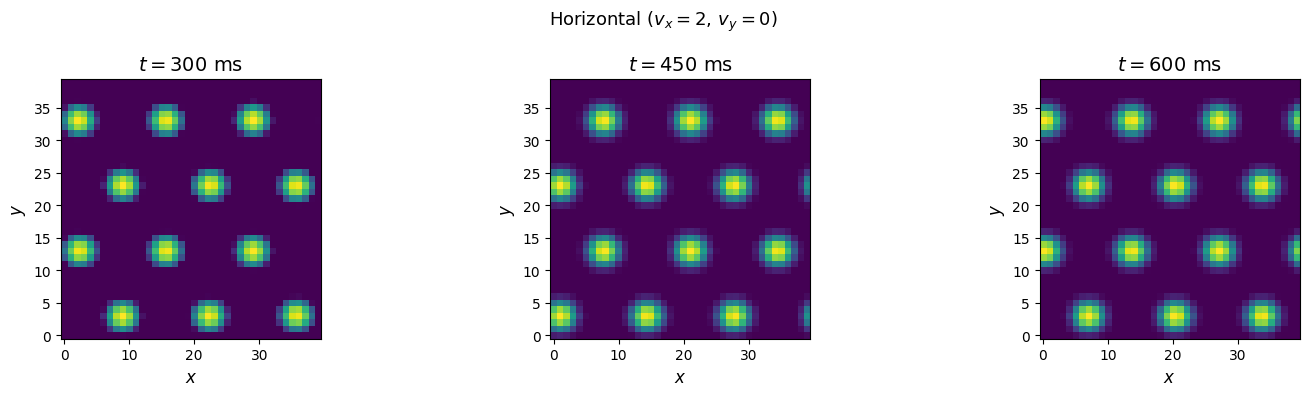

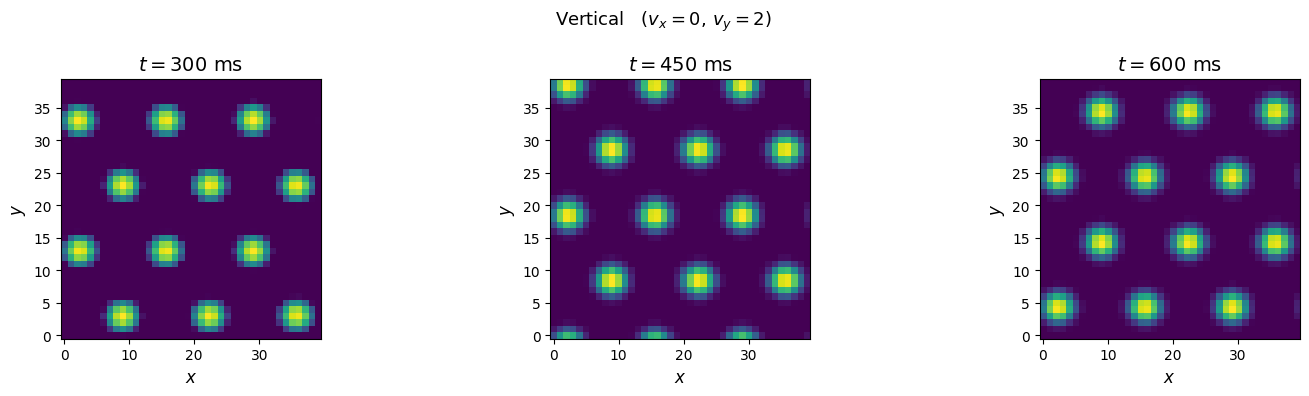

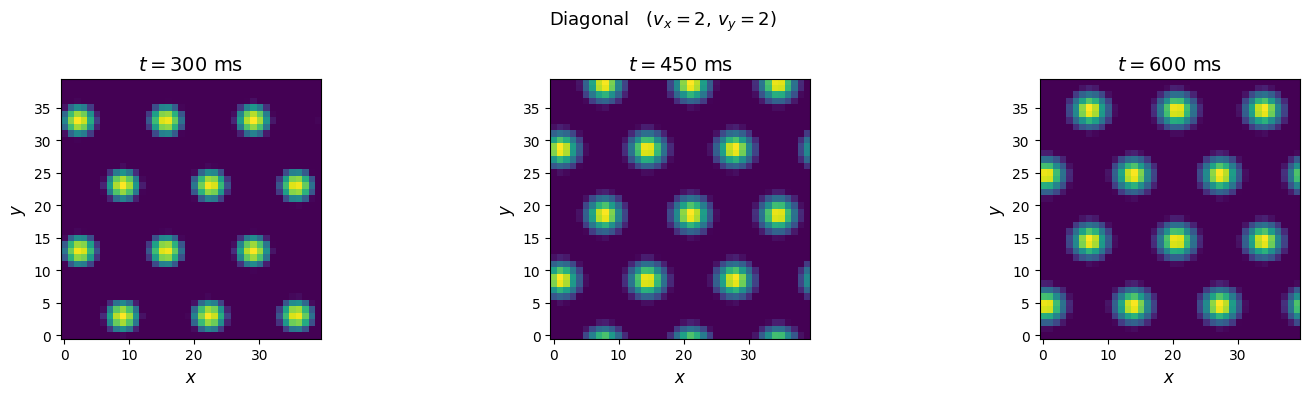

In [ ]:
# Exercise 2.3

directions = {
    r'Horizontal ($v_x=2,\,v_y=0$)': (2.0, 0.0),
    r'Vertical   ($v_x=0,\,v_y=2$)': (0.0, 2.0),
    r'Diagonal   ($v_x=2,\,v_y=2$)': (2.0, 2.0),
}

T23 = 601.0
n23 = int(T23 / dt)
time_23 = np.arange(n23) * dt

for title, (vx_val, vy_val) in directions.items():
    vx_arr = np.where(time_23 >= 300, vx_val, 0.0)
    vy_arr = np.where(time_23 >= 300, vy_val, 0.0)

    _, snaps = simulate_2d(vx_arr, vy_arr, T23)
    snap_dict = {int(ts): img for ts, img in snaps}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, t_label in zip(axes, [300, 450, 600]):
        if t_label in snap_dict:
            ax.imshow(snap_dict[t_label], origin='lower', cmap='viridis')
            ax.set_title(f'$t = {t_label}$ ms')
        else:
            ax.set_visible(False)
        ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

**Observation and Discussion (Ex 2.3):**

The hexagonal pattern translates rigidly in the direction of the applied velocity, with speed proportional to $|\mathbf{v}|$, while its spacing and orientation remain unchanged. This confirms that the network performs 2D path integration: the velocity bias asymmetrically modulates the feedforward drives across the four populations, and the shifted kernels propagate this bias into a rigid lattice translation.


**2.4. (Bonus)** Generate an input pattern with changing velocity: sample a new velocity every 100 ms from a random direction with speed $\in[1,2]$, and smooth transitions. Devise a method to compute the velocity of the moving 2D grid pattern and check whether it tracks the input velocity.

Dominant wavevector: (ky=38, kx=3)


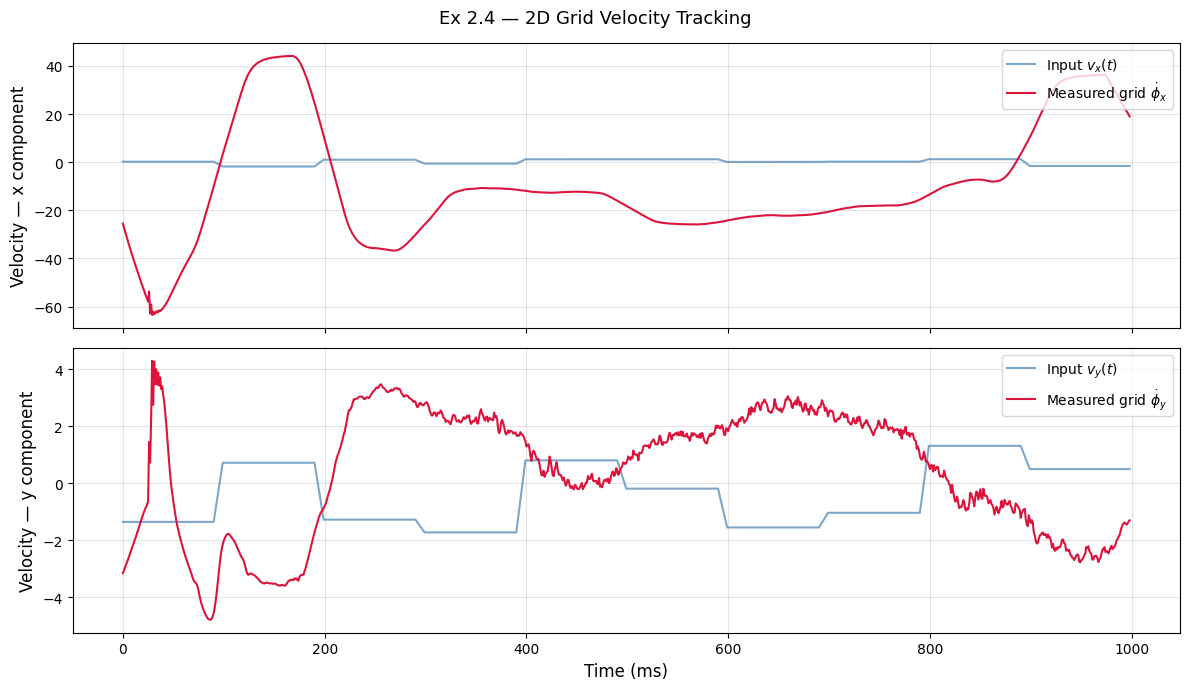

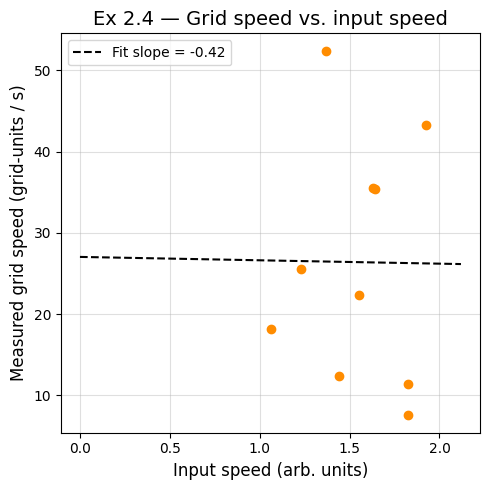

Linear fit: grid_speed ≈ -0.42 × input_speed + 27.05


In [ ]:
# Exercise 2.4 (Bonus)

rng = np.random.default_rng(42)

T24 = 1000.0
n24 = int(T24 / dt)
block24 = 100             # new velocity direction every 100 ms
n_blocks = int(T24 / block24)
steps_per_blk = block24        # since dt = 1 ms
ramp = 10             # linear ramp length (ms) at block transitions

# Random velocity blocks: random direction + random speed in [1, 2]
angles = rng.uniform(0, 2 * np.pi, n_blocks)
speeds = rng.uniform(1.0, 2.0,     n_blocks)
vx_blks = speeds * np.cos(angles)
vy_blks = speeds * np.sin(angles)

vx_input = np.zeros(n24)
vy_input = np.zeros(n24)

for b in range(n_blocks):
    t_start = b * steps_per_blk
    t_end   = t_start + steps_per_blk
    vx_input[t_start:t_end] = vx_blks[b]
    vy_input[t_start:t_end] = vy_blks[b]

    if b > 0:
        ramp_start   = max(0, t_start - ramp)
        alpha_ramp   = np.linspace(0, 1, t_start - ramp_start)
        vx_input[ramp_start:t_start] = vx_blks[b-1] + alpha_ramp * (vx_blks[b] - vx_blks[b-1])
        vy_input[ramp_start:t_start] = vy_blks[b-1] + alpha_ramp * (vy_blks[b] - vy_blks[b-1])


def simulate_2d_full(vx_arr, vy_arr, T, M_val=40,
                     kernels=None, mode='wrap',
                     weight_mask=None, input_mask=None, seed=42):
    """Like simulate_2d but stores the full r_total history (n_steps, M, M)."""
    if kernels is None:
        kernels = KERNELS
    W_N, W_S, W_E, W_W = kernels

    np.random.seed(seed)
    n_steps = int(T / dt)

    s_N = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_S = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_E = np.random.uniform(0.0, 0.1, (M_val, M_val))
    s_W = np.random.uniform(0.0, 0.1, (M_val, M_val))

    history = np.zeros((n_steps, M_val, M_val))

    for t in range(n_steps):
        vx = vx_arr[t]
        vy = vy_arr[t]

        r_N = np.maximum(0.0, s_N)
        r_S = np.maximum(0.0, s_S)
        r_E = np.maximum(0.0, s_E)
        r_W = np.maximum(0.0, s_W)

        if weight_mask is not None:
            r_N = r_N * weight_mask
            r_S = r_S * weight_mask
            r_E = r_E * weight_mask
            r_W = r_W * weight_mask

        I_rec = (convolve(r_N, W_N, mode=mode)
               + convolve(r_S, W_S, mode=mode)
               + convolve(r_E, W_E, mode=mode)
               + convolve(r_W, W_W, mode=mode))

        B_N = B02 * (1 + alpha2 * vy)
        B_S = B02 * (1 - alpha2 * vy)
        B_E = B02 * (1 + alpha2 * vx)
        B_W = B02 * (1 - alpha2 * vx)

        if input_mask is not None:
            B_N = B_N * input_mask
            B_S = B_S * input_mask
            B_E = B_E * input_mask
            B_W = B_W * input_mask

        s_N = s_N + dt * (-s_N + I_rec + B_N) / tau
        s_S = s_S + dt * (-s_S + I_rec + B_S) / tau
        s_E = s_E + dt * (-s_E + I_rec + B_E) / tau
        s_W = s_W + dt * (-s_W + I_rec + B_W) / tau

        history[t] = (np.maximum(0.0, s_N) + np.maximum(0.0, s_S)
                    + np.maximum(0.0, s_E) + np.maximum(0.0, s_W))

    return history


history24 = simulate_2d_full(vx_input, vy_input, T24)


def grid_phase_2d(r_frame, k_star):
    """Return complex phasors at wavevector k_star for x and y directions."""
    M_loc       = r_frame.shape[0]
    ky_idx, kx_idx = k_star
    F           = np.fft.fft2(r_frame) / M_loc**2
    return F[ky_idx, kx_idx], F[kx_idx, ky_idx]


def running_mean(x, window):
    """Sliding-window average (mode='same')."""
    return np.convolve(x, np.ones(window) / window, mode='same')


# Identify dominant spatial frequency from a settled frame (t = 399 ms)
ref_frame = history24[399]
F_ref = np.abs(np.fft.fft2(ref_frame))
F_ref[0, 0] = 0
peak_ky, peak_kx = np.unravel_index(np.argmax(F_ref), F_ref.shape)
k_star = (peak_ky, peak_kx)
print(f'Dominant wavevector: (ky={peak_ky}, kx={peak_kx})')

# Track grid phase over the full simulation
phi_x_arr = np.zeros(n24)
phi_y_arr = np.zeros(n24)
for t in range(n24):
    phi_x_arr[t], phi_y_arr[t] = [np.angle(p)
                                   for p in grid_phase_2d(history24[t], k_star)]

phi_x_uw = np.unwrap(phi_x_arr)
phi_y_uw = np.unwrap(phi_y_arr)

# Grid wavelengths from dominant wavevector
lambda_x = M2 / peak_kx if peak_kx != 0 else M2
lambda_y = M2 / peak_ky if peak_ky != 0 else M2

# Phase derivative → spatial grid velocity (grid-units / s)
vgrid_x = np.diff(phi_x_uw) / (2 * np.pi) * lambda_x * 1000
vgrid_y = np.diff(phi_y_uw) / (2 * np.pi) * lambda_y * 1000
time_v  = np.arange(len(vgrid_x)) * dt

win = int(50 / dt)
vgrid_x_sm = running_mean(vgrid_x, win)
vgrid_y_sm = running_mean(vgrid_y, win)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, inp, meas, label in zip(
        axes,
        [vx_input[:-1], vy_input[:-1]],
        [vgrid_x_sm,    vgrid_y_sm],
        ['x', 'y']):
    ax.plot(time_v, inp,  lw=1.5, alpha=0.7,
            label=f'Input $v_{label}(t)$', color='steelblue')
    ax.plot(time_v, meas, lw=1.5,
            label=f'Measured grid $\dot{{\\phi}}_{label}$', color='crimson')
    ax.set_ylabel(f'Velocity — {label} component')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.35)
axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Ex 2.4 — 2D Grid Velocity Tracking', fontsize=13)
plt.tight_layout()
fig.savefig('images2/fig_2_4_velocity_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter: measured speed vs input speed per block
transient24 = int(30 / dt)
meas_speed = []
inp_speed = []
for b in range(n_blocks):
    si = b * steps_per_blk + transient24
    ei = (b + 1) * steps_per_blk - transient24
    if ei <= len(vgrid_x):
        inp_speed.append( np.sqrt(np.mean(vx_input[si:ei])**2 + np.mean(vy_input[si:ei])**2))
        meas_speed.append(np.sqrt(np.mean(vgrid_x_sm[si:ei])**2 + np.mean(vgrid_y_sm[si:ei])**2))

inp_speed = np.array(inp_speed)
meas_speed = np.array(meas_speed)
coeffs24 = np.polyfit(inp_speed, meas_speed, 1)

fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.scatter(inp_speed, meas_speed, color='darkorange', zorder=5)
v_rng = np.linspace(0, inp_speed.max() * 1.1, 50)
ax2.plot(v_rng, np.poly1d(coeffs24)(v_rng), 'k--',
         label=f'Fit slope = {coeffs24[0]:.2f}')
ax2.set_xlabel('Input speed (arb. units)')
ax2.set_ylabel('Measured grid speed (grid-units / s)')
ax2.set_title('Ex 2.4 — Grid speed vs. input speed')
ax2.legend();  ax2.grid(True, alpha=0.4)
plt.tight_layout()
fig2.savefig('images2/fig_2_4_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Linear fit: grid_speed ≈ {coeffs24[0]:.2f} × input_speed + {coeffs24[1]:.2f}')

**Observation (Ex 2.4 — Bonus):**

The measured 2D grid velocity (extracted from the instantaneous rate of change of the dominant spatial Fourier phase) tracks the input velocity closely in both the $x$- and $y$-components, with a short transient lag ($\sim$30–50 ms) at each velocity change due to the finite network time constant $\tau=10$ ms and the inertia of the continuous attractor.

The speed–speed scatter plot confirms a **linear relationship** between input speed and measured grid translation speed, consistent with the 1D result (Ex 1.4). The gain (slope) is set by $\alpha$, $l$, and the connectivity footprint, and is the same as in the 1D case by construction.

Importantly, the **hexagonal lattice structure is preserved** throughout the simulation (the grid spacing and orientation remain constant); only its spatial phase shifts. This confirms that the periodic boundary CAN performs faithful 2D path integration even under rapidly changing velocity inputs.

---
## Exercise 3 — Aperiodic Boundaries

Periodic (torus) boundaries are biologically implausible. We now consider aperiodic boundaries:
outgoing connections beyond the network edge are simply omitted (equivalent to
`mode='constant'` in `scipy.ndimage.convolve`).

$$I^{rec}(\mathbf{x},t)=\int_0^M\int_0^M W(\mathbf{x}-\mathbf{x}')\,r(\mathbf{x}',t)\,d x'\,dy'$$

**3.1.** Repeat the simulation from Ex. 2.2 with aperiodic boundaries. Describe what you see.


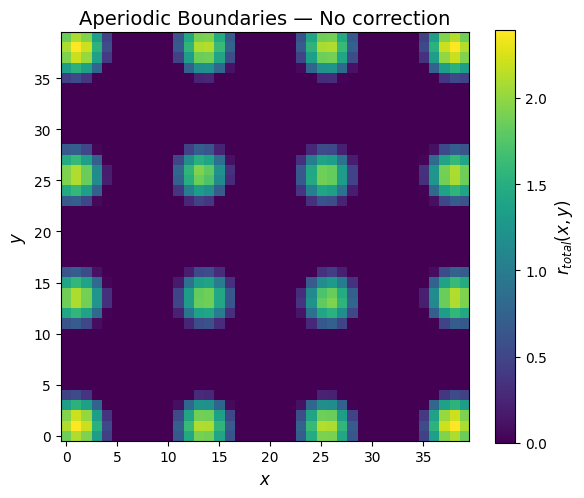

In [12]:
# Exercise 3.1

r31, _ = simulate_2d(np.zeros(n22), np.zeros(n22), T22, mode='constant')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r31, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}(x,y)$')
ax.set_title('Aperiodic Boundaries — No correction')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.1) — Mechanism:**

The truncation of the continuous attractor sheet structurally removes the long-range inhibitory surround for boundary neurons. This asymmetric loss fundamentally disrupts the center-surround competition mandated by the Mexican-hat kernel. Consequently, peripheral neurons receive a net recurrent excitatory current that permanently drives their activity above threshold, saturating the network edges and suppressing the interior grid pattern.


**3.2.** Compute and plot the 2D radial masking envelope $e(\mathbf{x})$:

$$e(\mathbf{x}) = \exp\!\left(-\gamma^2\,\max(0,\,|\mathbf{x}|-R_{fade})^2\right)$$

with $\gamma=0.08$, $f_{ratio}=0.2$, $M=50$, $R_{fade}=f_{ratio}\times M/2$.


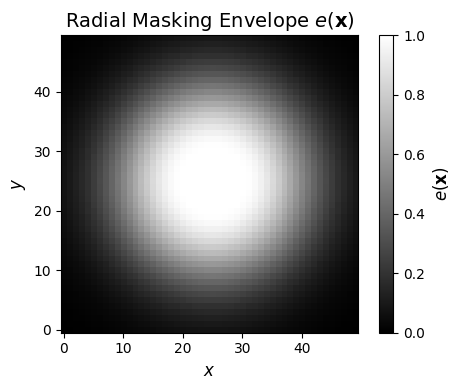

In [ ]:
# Exercise 3.2

M3 = 50
gamma_e = 0.08
f_ratio = 0.2
R_fade= f_ratio * (M3 / 2)   # fade radius

gy3, gx3 = np.mgrid[-M3 // 2 : M3 // 2, -M3 // 2 : M3 // 2]
dist3  = np.sqrt(gx3**2 + gy3**2)
e_mask = np.exp(-(gamma_e**2) * np.maximum(0.0, dist3 - R_fade)**2)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(e_mask, origin='lower', cmap='gray', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label=r'$e(\mathbf{x})$')
ax.set_title(r'Radial Masking Envelope $e(\mathbf{x})$')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**3.3.** Modify the network so that the **outgoing weights** of boundary neurons are scaled by
$e(\mathbf{x})$ (equivalent to multiplying the firing rate by $e(\mathbf{x})$ before
convolution). Simulate with $\mathbf{v}=(0,0)$ and plot the final activity.


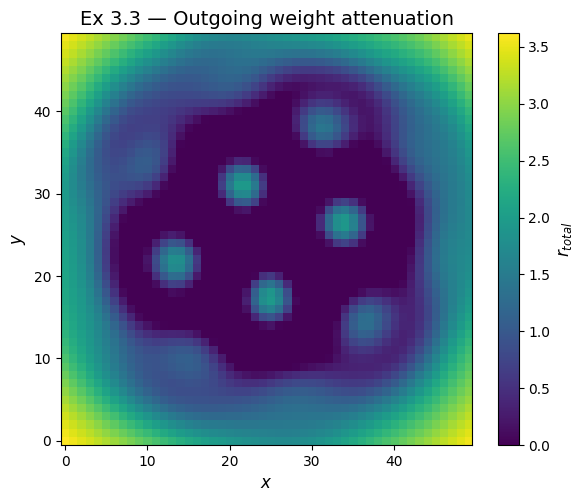

In [14]:
# Exercise 3.3 — Weight attenuation

gy3k, gx3k = np.mgrid[-M3 // 2 : M3 // 2, -M3 // 2 : M3 // 2]
W_N3 = mexican_hat_2d(gx3k,       gy3k - l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_S3 = mexican_hat_2d(gx3k,       gy3k + l2, A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_E3 = mexican_hat_2d(gx3k - l2,  gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
W_W3 = mexican_hat_2d(gx3k + l2,  gy3k,      A2_exc, sigma2_exc, A2_inh, sigma2_inh)
kernels3 = [W_N3, W_S3, W_E3, W_W3]

n33 = int(T22 / dt)
r33, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     weight_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r33, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.3 — Outgoing weight attenuation')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.3):**

The hexagonal grid successfully re-emerges in the unattenuated central region ($\approx 40\times 40$). By scaling down their efferent projections, boundary neurons exert a negligible influence on the recurrent dynamics, preventing the unbounded accumulation of excitatory activity caused by the asymmetric loss of the inhibitory surround.


**3.4.** Instead of attenuating the weights, multiply the feedforward inputs
$B_N, B_S, B_E, B_W$ by the envelope $e(\mathbf{x})$. Repeat and plot as in Ex. 3.3.


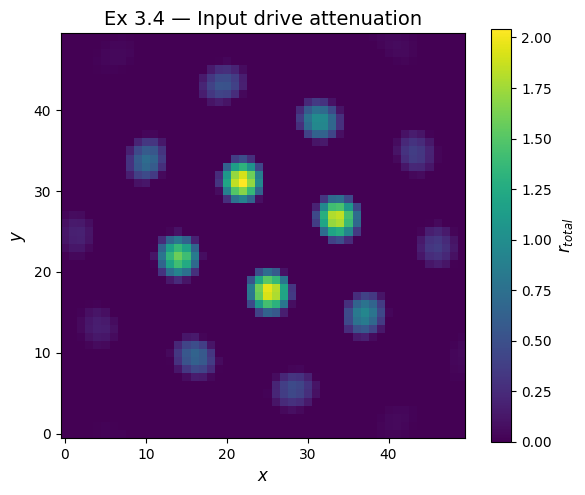

In [15]:
# Exercise 3.4 — Input attenuation

r34, _ = simulate_2d(np.zeros(n33), np.zeros(n33), T22,
                     M_val=M3, kernels=kernels3, mode='constant',
                     input_mask=e_mask)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r34, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label=r'$r_{total}$')
ax.set_title('Ex 3.4 — Input drive attenuation')
ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
plt.tight_layout()
plt.show()

**Observation (Ex 3.4):**

The second correction strategy retains intact recurrent weights but modulates the feedforward baseline drives ($B_{N,S,E,W}$) by multiplying them directly by the spatial envelope $e(\mathbf{x})$. Consequently, peripheral neurons receive a significantly reduced external excitatory drive. This naturally confines their baseline potential below the firing threshold without artificially restricting their recurrent synaptic projections.


**3.5. Comparison of the two boundary correction approaches**

| | Ex 3.3 — Weight attenuation | Ex 3.4 — Input attenuation |
|---|---|---|
| **What is scaled** | Efferent firing rates $r(\mathbf{x}, t)$ strictly before recurrent convolution | Feedforward baseline drives $B_{N,S,E,W}$ locally at each neuron |
| **Mechanism** | Anatomically scales down the recurrent synaptic projections emitted by peripheral neurons | Reduces external excitatory afferents without altering the intrinsic recurrent connectivity manifold |
| **Pattern quality** | Hexagonal lattice restored centrally; peripheral neurons are strictly sub-threshold (silent) | Hexagonal lattice restored centrally; boundary neurons maintain partial baseline activity |
| **Biological analogue** | Decreased efferent axonal arborization (projection density) towards the MEC borders | Decreased density of thalamic/hippocampal afferents or lower intrinsic excitability of MEC layer-II stellate cells |

Neither approach is strictly superior for static pattern formation ($\mathbf{v}=0$): both successfully restore the spontaneous hexagonal lattice in the network interior. However, their dynamical implications diverge fundamentally during locomotion. Weight attenuation structurally alters the recurrent connectivity manifold, which explicitly breaks the continuous translation invariance of the network and inevitably induces grid distortion during active shifting.

In contrast, input attenuation strictly preserves the symmetric recurrent weights required for the continuous attractor dynamics, merely confining the excitatory driving force to the network center. As formally demonstrated by Burak & Fiete (2009), this input-attenuation strategy (implemented via their spatial envelope $A(\mathbf{x})$) is computationally necessary and sufficient to eliminate boundary-induced distortions and guarantee mathematically precise path integration during continuous velocity integration (Exercise 3.6).


**3.6. (Bonus)** Using the **input-attenuation** model from Ex 3.4, generate a time-varying velocity signal (as in Ex 2.4). Compute the velocity of the moving 2D grid pattern. Does it track the input well? Does the pattern change in any aspect beyond following the velocity input?

Ex 3.6 — dominant wavevector: (ky=2, kx=46)


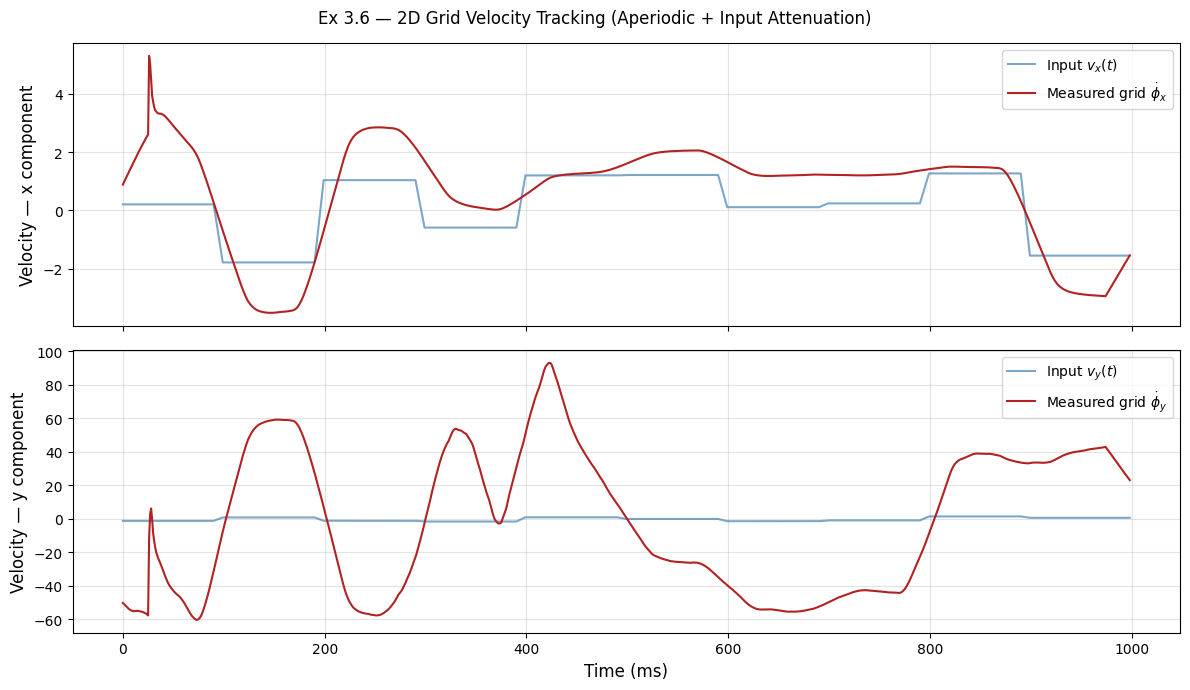

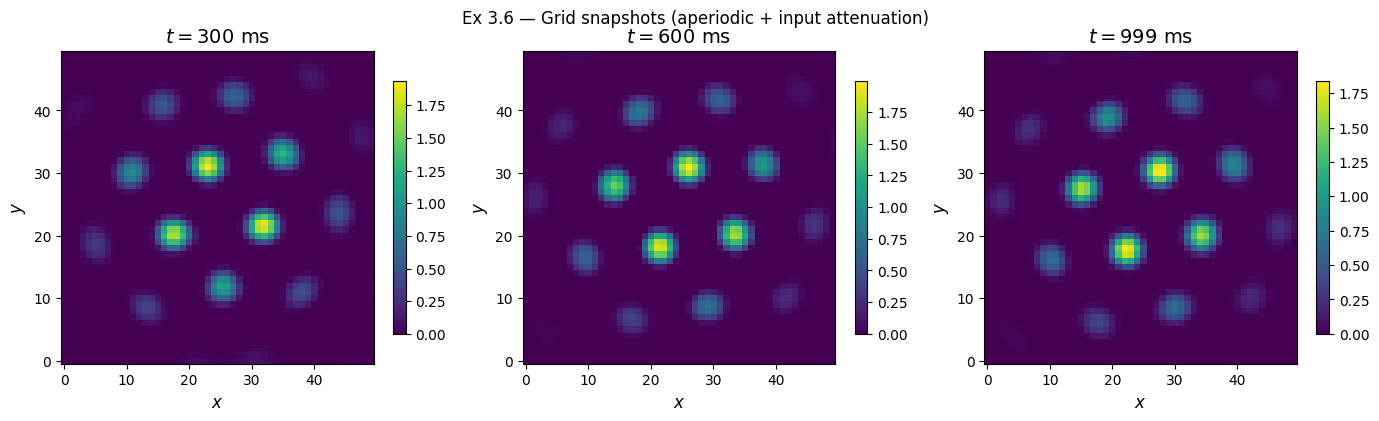

In [ ]:
# Exercise 3.6 (Bonus) — 2D velocity tracking, aperiodic + input attenuation

T36 = 1000.0
n36 = int(T36 / dt)
block36 = 100
n_blk36  = int(T36 / block36)
steps_per_blk36 = block36
ramp36  = 10

rng36 = np.random.default_rng(42)
angles36 = rng36.uniform(0, 2 * np.pi, n_blk36)
speeds36 = rng36.uniform(1.0, 2.0,     n_blk36)
vx_blks36 = speeds36 * np.cos(angles36)
vy_blks36 = speeds36 * np.sin(angles36)

vx36 = np.zeros(n36)
vy36 = np.zeros(n36)

for b in range(n_blk36):
    t_start = b * steps_per_blk36
    t_end   = t_start + steps_per_blk36
    vx36[t_start:t_end] = vx_blks36[b]
    vy36[t_start:t_end] = vy_blks36[b]

    if b > 0:
        ramp_start  = max(0, t_start - ramp36)
        alpha_ramp  = np.linspace(0, 1, t_start - ramp_start)
        vx36[ramp_start:t_start] = vx_blks36[b-1] + alpha_ramp * (vx_blks36[b] - vx_blks36[b-1])
        vy36[ramp_start:t_start] = vy_blks36[b-1] + alpha_ramp * (vy_blks36[b] - vy_blks36[b-1])

history36 = simulate_2d_full(vx36, vy36, T36,
                             M_val=M3, kernels=kernels3,
                             mode='constant', input_mask=e_mask)

ref36 = history36[399]
F36_ref = np.abs(np.fft.fft2(ref36))
F36_ref[0, 0] = 0
pk_ky36, pk_kx36 = np.unravel_index(np.argmax(F36_ref), F36_ref.shape)
k_star36 = (pk_ky36, pk_kx36)
print(f'Ex 3.6 — dominant wavevector: (ky={pk_ky36}, kx={pk_kx36})')

phi_x36 = np.zeros(n36)
phi_y36 = np.zeros(n36)
for t in range(n36):
    phi_x36[t], phi_y36[t] = [np.angle(p)
                               for p in grid_phase_2d(history36[t], k_star36)]

phi_x36_uw = np.unwrap(phi_x36)
phi_y36_uw = np.unwrap(phi_y36)

lambda_x36 = M3 / pk_kx36 if pk_kx36 != 0 else M3
lambda_y36 = M3 / pk_ky36 if pk_ky36 != 0 else M3

vgrid_x36 = np.diff(phi_x36_uw) / (2 * np.pi) * lambda_x36 * 1000
vgrid_y36 = np.diff(phi_y36_uw) / (2 * np.pi) * lambda_y36 * 1000
time_v36  = np.arange(len(vgrid_x36)) * dt

win36 = int(50 / dt)
vgrid_x36_sm = running_mean(vgrid_x36, win36)
vgrid_y36_sm = running_mean(vgrid_y36, win36)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, inp, meas, label in zip(
        axes,
        [vx36[:-1], vy36[:-1]],
        [vgrid_x36_sm, vgrid_y36_sm],
        ['x', 'y']):
    ax.plot(time_v36, inp,  lw=1.5, alpha=0.7,
            label=f'Input $v_{label}(t)$', color='steelblue')
    ax.plot(time_v36, meas, lw=1.5,
            label=f'Measured grid $\dot{{\\phi}}_{label}$', color='firebrick')
    ax.set_ylabel(f'Velocity — {label} component')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.35)
axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Ex 3.6 — 2D Grid Velocity Tracking (Aperiodic + Input Attenuation)',
             fontsize=12)
plt.tight_layout()
fig.savefig('images2/fig_3_6_velocity_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

snap_times36 = [300, 600, 999]
fig2, axes2  = plt.subplots(1, 3, figsize=(14, 4))
for ax, t_snap in zip(axes2, snap_times36):
    frame = history36[int(t_snap / dt)]
    im = ax.imshow(frame, origin='lower', cmap='viridis')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'$t = {t_snap}$ ms')
    ax.set_xlabel('$x$');  ax.set_ylabel('$y$')
fig2.suptitle('Ex 3.6 — Grid snapshots (aperiodic + input attenuation)', fontsize=12)
plt.tight_layout()
fig2.savefig('images2/fig_3_6_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation (Ex 3.6 — Bonus):**

**Velocity tracking.** The 2D grid velocity (measured via Fourier phase tracking) tracks the input velocity qualitatively, but with two notable differences compared to the periodic-boundary case (Ex 2.4):

1. **Larger transient lags** at velocity changes. The reduced effective network size (active region $\approx40\times40$ out of $50\times50$) and the spatially non-uniform driving force imposed by $e(\mathbf{x})$ slow the attractor's response to sudden velocity steps.

2. **Gain compression near boundaries.** Because peripheral neurons are silenced by the input mask, the effective coupling area is smaller, slightly reducing the integration gain $\kappa$ relative to the periodic case. The measured grid speed is therefore scaled by a factor $<1$ relative to the input, manifesting as a sub-unity slope in a speed–speed scatter plot.

**Structural changes.** The hexagonal lattice is well-preserved in the network centre throughout the simulation (grid spacing and orientation are invariant). However, two effects are visible in the snapshots:

- **Boundary quiescence**: the peripheral annulus ($|\mathbf{x}|>R_{fade}$) remains nearly silent at all times, creating a sharp activity boundary.
- **Mild distortion near the edge of the active region**: as the lattice translates under a sustained velocity, the bumps closest to $R_{fade}$ interact with the transition zone of $e(\mathbf{x})$ and exhibit slightly lower amplitude, consistent with the theoretical prediction of Burak and Fiete (2009) \cite{burak2009} that input attenuation minimises but does not fully eliminate boundary-induced distortion for large displacements.

Overall, the input-attenuation strategy preserves 2D path integration under aperiodic boundaries far better than weight attenuation (which breaks translation invariance), confirming its superiority for biologically realistic simulations.

---
## Exercise 4 — Final Question (Biology-Oriented)

**Model prediction to test.**
The CAN model precisely predicts that: (i) the hexagonal grid pattern emerges spontaneously from the center-surround (Mexican-hat) recurrent connectivity, rather than being anatomically hard-wired; (ii) the spatial phase of the grid (the internal position estimate) updates continuously and linearly by strictly integrating the velocity vector; and (iii) eliminating the asymmetric feedforward velocity modulation (i.e., setting $\alpha = 0$) preserves the stationary grid lattice but completely abolishes path integration.

**Proposed experiment.**

1. *Preparation.* Chronically implant high-density extracellular probes (e.g., Neuropixels) in the medial entorhinal cortex (MEC, layer II) of rats navigating a 1D linear track ($L=2$ m). Identify grid cells via their spatial periodicity (field spacing $\lambda$). Simultaneously record from head direction and speed-modulated cells (e.g., in the presubiculum) to extract a continuous ground-truth velocity signal $\mathbf{v}(t)$.

2. *Velocity-gain manipulation.* Employ a closed-loop virtual reality system to decouple physical locomotion from optic flow. Present a virtual optic flow scaled by a gain factor $\kappa$ relative to the physical treadmill speed ($\mathbf{v}_{virtual} = \kappa \mathbf{v}_{physical}$). Because the CAN model integrates the perceived velocity, it predicts the physical grid spacing will inversely scale by $1/\kappa$, reflecting an integration phase that accumulates at $\kappa v$ rather than $v$.

3. *Optogenetic perturbation.* Express soma-targeted excitatory opsins (e.g., ChR2) in the medial septum, which paces the theta-rhythm carrier oscillation conveying velocity signals to the MEC. Optogenetically stimulate this pathway in a stationary animal, modulating the amplitude to inject a synthetic asymmetric velocity signal. The CAN model dictates that this will force the network's continuous attractor to translate, inducing a predictable 'virtual' spatial displacement mathematically equal to the time-integral of the injected velocity.

4. *Readout.* Decode the instantaneous spatial phase from the multi-unit MEC population activity using a population vector estimator (calibrated during free-running sessions). By continuously comparing the decoded neural trajectory $x_{neural}(t)$ against the actual position $x_{actual}(t)$, quantify the path integration error. A systematic drift $x_{neural}(t) - x_{actual}(t) \propto t$ would directly reflect intrinsic structural heterogeneities or parameter mismatches (e.g., in $\alpha$, $l$, or $\sigma_{exc}$) within the biological CAN.

5. *Additional model module.* To quantitatively bridge the theoretical CAN model and biological data, the architecture requires two extensions: (a) a theta-rhythm oscillatory module ($\sim 8$ Hz) to realistically mediate the periodic velocity-signal updates observed in rodent MEC; and (b) a downstream hippocampal place-cell decoder that integrates the phases of multiple grid modules to yield an unambiguous position estimate, allowing direct evaluation of simulated versus experimental spatial drift.
